In [1]:
from sklearn import svm, metrics
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from imblearn.under_sampling import RandomUnderSampler
import joblib
from sklearn.inspection import permutation_importance 
import os
from sklearn.metrics import PrecisionRecallDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# CNN features

In [2]:
features_efficient_net = np.load('./data/embeddings.npz', allow_pickle=True)
features_efficient_net
features_cnn_data = features_efficient_net

In [3]:
features_cnn_data['embeddings'].shape


(17264, 2048)

# Classic features

In [4]:
dataset = pd.read_csv('./data/02_dataset_w_features.csv', index_col=0)
dataset = dataset.sort_values('image').reset_index(drop=True)
# Filter rows where total_y and total_x are 0
mask = (dataset['total_x'] == 0.0) & (dataset['total_y'] == 0.0)
dataset = dataset[~mask].dropna()
dataset = dataset.drop_duplicates(subset=['image'], keep=False, inplace=False, ignore_index=False)
dataset

,image,dx,path,diameter,compactness,circularity,saturation_std,val_std,total_x,total_y,...,p16,p17,p18,p19,p20,p21,p22,p23,p24,p25
0,ISIC_0000000,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000000.jpg,215.0,15.028339,0.836178,14.867868,48.596631,0.735999,0.807093,...,828.0,630.0,511.0,456.0,425.0,419.0,484.0,586.0,1073.0,11004.0
1,ISIC_0000001,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000001.jpg,93.0,14.465422,0.868718,39.563723,40.721247,0.527757,0.834138,...,222.0,157.0,138.0,108.0,82.0,65.0,55.0,66.0,155.0,1540.0
2,ISIC_0000002,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0000002.jpg,199.0,15.029097,0.836136,29.217215,30.506347,0.519741,0.674537,...,644.0,452.0,441.0,363.0,298.0,319.0,362.0,371.0,808.0,7395.0
3,ISIC_0000003,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000003.jpg,224.0,15.630267,0.803977,41.837675,39.772489,0.737595,0.825801,...,589.0,487.0,391.0,370.0,403.0,457.0,405.0,434.0,749.0,8703.0
4,ISIC_0000004,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0000004.jpg,154.0,14.947698,0.840689,30.712033,22.264115,0.199741,0.552067,...,230.0,214.0,169.0,175.0,208.0,198.0,255.0,292.0,639.0,5668.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17259,ISIC_0073241,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0073241.jpg,201.0,15.633038,0.803834,20.542154,12.875236,0.462161,0.581317,...,497.0,447.0,382.0,443.0,467.0,528.0,540.0,503.0,1199.0,10778.0
17260,ISIC_0073244,NV,/Downloads/ISIC_2019/images/NV/ISIC_0073244.jpg,243.0,14.954783,0.840291,22.701976,28.670436,0.793519,0.796575,...,963.0,723.0,589.0,520.0,472.0,543.0,612.0,687.0,1440.0,12453.0
17261,ISIC_0073245,NV,/Downloads/ISIC_2019/images/NV/ISIC_0073245.jpg,186.0,14.806641,0.848698,35.277772,23.732672,0.680089,0.794475,...,540.0,501.0,423.0,414.0,398.0,359.0,390.0,417.0,1114.0,8766.0
17262,ISIC_0073249,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0073249.jpg,244.0,16.619260,0.756133,26.627686,37.776683,0.817845,0.594902,...,1204.0,1002.0,847.0,727.0,695.0,691.0,720.0,677.0,1562.0,12658.0


In [5]:
dataset['dx'].value_counts()

dx
NV     12792
MEL     4472
Name: count, dtype: int64

### Filter valid

In [6]:
valid_ids = dataset['image'].values
mask_ids = np.isin(features_cnn_data['base_ids'], valid_ids)
embeddings_valid = features_cnn_data['embeddings'][mask_ids]
id_embeddings = features_cnn_data['base_ids'][mask_ids]

In [7]:
X_classic = dataset[['diameter', 'circularity', 'total_x', 'total_y'] + [f'p{i}' for i in range(26)]] 
X_cnn = embeddings_valid
y = dataset['dx'].values

### Split

In [8]:
X_train_classic, X_test_classic, X_train_cnn, X_test_cnn, y_train, y_test = train_test_split(X_classic, X_cnn, y, test_size=0.2, stratify=y, random_state=42) 

In [9]:
X_test_classic

,diameter,circularity,total_x,total_y,p0,p1,p2,p3,p4,p5,...,p16,p17,p18,p19,p20,p21,p22,p23,p24,p25
4626,208.0,0.726001,0.289656,0.588047,720.0,404.0,413.0,330.0,274.0,225.0,...,256.0,258.0,256.0,228.0,254.0,294.0,388.0,551.0,882.0,9080.0
13991,197.0,0.850455,0.732871,0.885076,694.0,330.0,243.0,233.0,212.0,270.0,...,646.0,532.0,418.0,346.0,323.0,312.0,318.0,335.0,862.0,7927.0
8865,192.0,0.814490,0.681726,0.707489,722.0,327.0,265.0,287.0,316.0,402.0,...,655.0,565.0,485.0,474.0,418.0,411.0,364.0,399.0,873.0,7754.0
12335,145.0,0.811400,0.491694,0.630887,442.0,269.0,153.0,105.0,118.0,138.0,...,215.0,164.0,139.0,138.0,130.0,161.0,199.0,263.0,544.0,5070.0
13760,166.0,0.711325,0.756224,0.797552,707.0,399.0,290.0,234.0,230.0,222.0,...,433.0,380.0,306.0,309.0,270.0,280.0,330.0,379.0,861.0,7671.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11145,55.0,0.848861,0.052415,0.624545,20.0,13.0,9.0,4.0,8.0,5.0,...,62.0,39.0,36.0,28.0,15.0,9.0,28.0,28.0,38.0,325.0
8603,256.0,0.759490,0.726492,0.861335,1171.0,664.0,582.0,542.0,542.0,580.0,...,821.0,687.0,601.0,539.0,513.0,574.0,645.0,745.0,1436.0,15455.0
3378,202.0,0.801933,0.793245,0.745788,937.0,422.0,401.0,392.0,423.0,437.0,...,714.0,608.0,501.0,472.0,440.0,495.0,444.0,398.0,1146.0,8825.0
7976,256.0,0.774732,0.865630,0.896423,2355.0,1351.0,1280.0,1207.0,1024.0,897.0,...,1233.0,1055.0,938.0,909.0,1010.0,968.0,1144.0,1221.0,3098.0,23687.0


In [10]:
dataset['path'][11145]

'/Downloads/ISIC_2019/images/NV/ISIC_0055860.jpg'

### Normalize and Stack features

In [11]:
X_train_classic_pd = pd.concat([X_train_classic.reset_index(drop=True), pd.DataFrame({'dx':y_train}).reset_index(drop=True)], axis=1)
X_train_classic_pd


,diameter,circularity,total_x,total_y,p0,p1,p2,p3,p4,p5,...,p17,p18,p19,p20,p21,p22,p23,p24,p25,dx
0,84.0,0.845578,0.425323,0.767490,166.0,87.0,60.0,51.0,75.0,70.0,...,98.0,90.0,67.0,62.0,76.0,100.0,105.0,209.0,2088.0,NV
1,164.0,0.801118,0.129290,0.751820,356.0,159.0,125.0,129.0,162.0,147.0,...,305.0,243.0,220.0,183.0,216.0,198.0,192.0,444.0,3783.0,NV
2,54.0,0.861179,0.073889,0.833966,12.0,16.0,14.0,14.0,15.0,14.0,...,56.0,38.0,34.0,34.0,23.0,22.0,27.0,52.0,598.0,NV
3,113.0,0.770715,0.323160,0.246564,89.0,37.0,35.0,44.0,36.0,66.0,...,129.0,124.0,94.0,91.0,75.0,62.0,46.0,70.0,1484.0,NV
4,175.0,0.732252,0.665331,0.630552,488.0,246.0,227.0,229.0,228.0,242.0,...,300.0,242.0,244.0,222.0,262.0,286.0,303.0,723.0,5824.0,NV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13806,46.0,0.854097,0.694301,0.696498,11.0,1.0,1.0,5.0,7.0,5.0,...,34.0,28.0,18.0,16.0,11.0,11.0,9.0,27.0,261.0,NV
13807,195.0,0.862314,0.886750,0.700694,821.0,418.0,398.0,380.0,349.0,404.0,...,522.0,505.0,504.0,487.0,446.0,424.0,360.0,1296.0,8068.0,MEL
13808,256.0,0.709162,0.508629,0.508435,1358.0,904.0,515.0,447.0,467.0,469.0,...,548.0,473.0,447.0,430.0,502.0,642.0,832.0,1671.0,17517.0,NV
13809,82.0,0.825277,0.355268,0.605344,128.0,87.0,61.0,58.0,53.0,49.0,...,28.0,28.0,23.0,17.0,19.0,48.0,152.0,195.0,1737.0,NV


In [12]:
q = [0.25, 0.50, 0.75, 0.90]

#Percentiles melanoma

melanoma_data = X_train_classic_pd[X_train_classic_pd['dx'] == 'MEL'] 
nevo_data = X_train_classic_pd[X_train_classic_pd['dx'] == 'NV'] 


In [13]:
melanoma_per = melanoma_data[['diameter', 'circularity', 'saturation_std', 'val_std', 'total_x', 'total_y', 'saturation_mean', 'val_mean']].quantile(q) 
nevo_per = nevo_data[['diameter', 'circularity', 'saturation_std', 'val_std', 'total_x', 'total_y', 'saturation_mean', 'val_mean']].quantile(q) 


melanoma_per.to_csv('./data/melanoma_percentiles.csv', index=False)
nevo_per.to_csv('./data/nevo_percentiles.csv', index=False)

KeyError: "['saturation_std', 'val_std', 'saturation_mean', 'val_mean'] not in index"

In [ ]:
scaler_classic = StandardScaler()
scaler_classic.fit(X_train_classic)
X_scaled_train_classic = scaler_classic.transform(X_train_classic)
X_scaled_test_classic = scaler_classic.transform(X_test_classic)


scaler_cnn = StandardScaler()
scaler_cnn.fit(X_train_cnn)
X_scaled_train_cnn = scaler_cnn.transform(X_train_cnn)
X_scaled_test_cnn = scaler_cnn.transform(X_test_cnn)



label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


In [ ]:
# Apply pca over cnn features.
pca = PCA(n_components=0.95)
X_cnn_train_pca = pca.fit_transform(X_scaled_train_cnn)
X_cnn_test_pca = pca.transform(X_scaled_test_cnn)

In [ ]:
pca.explained_variance_ratio_.sum()

np.float32(0.95005906)

In [ ]:
X_train_stacked = np.hstack([X_scaled_train_classic, X_cnn_train_pca ])
X_test_stacked = np.hstack([X_scaled_test_classic, X_cnn_test_pca])

In [ ]:
n_melanoma = np.sum(y_train_encoded == 0)
n_nevos = np.sum(y_train_encoded == 1)

ratio = n_nevos / n_melanoma

print(ratio)

2.859977641140302


In [ ]:

undersample = RandomUnderSampler(random_state=42, sampling_strategy=1)

X_train_stacked, y_train_encoded = undersample.fit_resample(X_train_stacked, y_train_encoded)

In [ ]:
pca.explained_variance_ratio_.sum()

np.float32(0.95005906)

# SVM classifier

In [ ]:
# parameters = [
#     {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1], 'class_weight': ['balanced', None]}
# ]

# model_svm = svm.SVC(probability=True)
# gridSe = GridSearchCV(model_svm, parameters, verbose=2)
# gridSe.fit(X_train_stacked, y_train_encoded)

# model_svm = gridSe.best_estimator_

# joblib.dump(gridSe.best_estimator_, './data/model_svm_every_feature.pkl')

In [ ]:
model_pkl = joblib.load('./data/model_svm_every_feature.pkl')
best_parameters = model_pkl.get_params()
best_parameters['class_weight'] = None
model_svm = svm.SVC(**best_parameters)
model_svm.fit(X_train_stacked, y_train_encoded)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
y_svm_pred = model_svm.predict(X_test_stacked)

print(classification_report(y_test_encoded, y_svm_pred))

              precision    recall  f1-score   support

           0       0.60      0.81      0.69       894
           1       0.93      0.81      0.86      2559

    accuracy                           0.81      3453
   macro avg       0.76      0.81      0.78      3453
weighted avg       0.84      0.81      0.82      3453



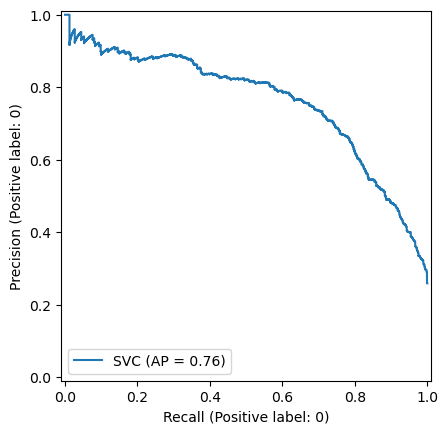

In [ ]:
PrecisionRecallDisplay.from_estimator(model_svm, X_test_stacked, y_test_encoded,pos_label=0)


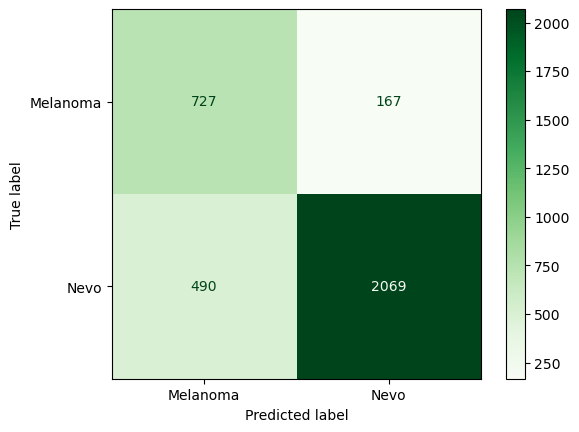

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    model_svm, X_test_stacked, y_test_encoded,
    display_labels=['Melanoma', 'Nevo'],
    cmap='Greens'
)

plt.show()


In [ ]:


# fpr, tpr, thresholds = metrics.roc_curve(y_test_encoded, y_scores)


# roc_auc = metrics.auc(fpr, tpr)
# print("AUC:", roc_auc)

# j = tpr - fpr

# optimal_thres = thresholds[np.argmax(j)]


# plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--') # Random guess line
# plt.show()
# print(optimal_thres)

In [ ]:
y_scores = model_svm.predict_proba(X_test_stacked)[:,0]

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test_encoded, y_scores, pos_label=0)

idx = np.where(recall >= 0.82)[0][-1]
idx = min(idx, len(thresholds) - 1)
optimal_thres = thresholds[idx]
print(f"Threshold: {thresholds[idx]}, Precision: {precision[idx]}, Recall: {recall[idx]}")

Threshold: 0.4949116806530155, Precision: 0.5872, Recall: 0.8210290827740492


In [ ]:
y_probs = model_svm.predict_proba(X_test_stacked)

y_pred = (y_scores >= optimal_thres).astype(int)

y_pred = 1-y_pred

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.82      0.68       894
           1       0.93      0.80      0.86      2559

    accuracy                           0.80      3453
   macro avg       0.76      0.81      0.77      3453
weighted avg       0.84      0.80      0.81      3453



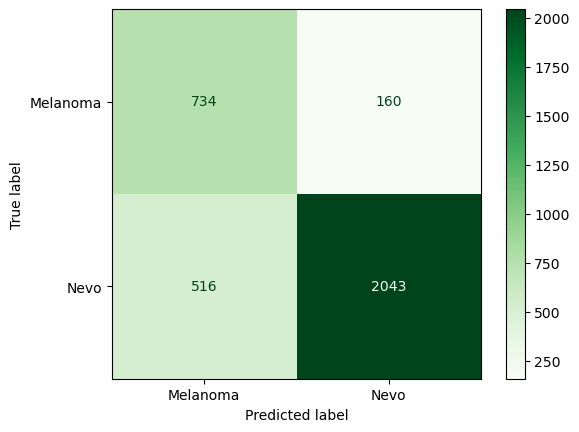

In [ ]:
ConfusionMatrixDisplay.from_predictions(
   y_test_encoded, y_pred,
    display_labels=['Melanoma', 'Nevo'],
    cmap='Greens'
)

plt.show()

In [ ]:
joblib.dump(model_svm, './data/model_svm_final.pkl')
joblib.dump(scaler_classic, './data/scaler_classic.pkl')
joblib.dump(scaler_cnn, './data/scaler_cnn.pkl')
joblib.dump(pca, './data/pca.pkl')
joblib.dump(label_encoder, './data/label_encoder.pkl')

['./data/label_encoder.pkl']